In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Set paths (change as per your folder structure)
train_dir = r"Desktop\Knee X-ray Images\processed_data_70_20_10\train"
val_dir = r"Desktop\Knee X-ray Images\processed_data_70_20_10\val"
test_dir = r"Desktop\Knee X-ray Images\processed_data_70_20_10\test"
batch_size = 32
img_size = (299, 299)
num_classes = 5
class_names = ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']  # Update as per your labels

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(train_dir, image_size=img_size, batch_size=batch_size)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(val_dir, image_size=img_size, batch_size=batch_size)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(test_dir, image_size=img_size, batch_size=batch_size, shuffle=False)


Found 1149 files belonging to 5 classes.
Found 333 files belonging to 5 classes.
Found 168 files belonging to 5 classes.


In [5]:
# Apply preprocessing
from tensorflow.keras.applications.inception_v3 import preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))


In [6]:
# Build model
base_model = InceptionV3(input_shape=img_size + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Add callback if needed (e.g., TensorBoard)
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir="./logs")

In [7]:
# Train model
history= model.fit(train_ds, validation_data=val_ds, epochs=30)


Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.3960 - loss: 1.5487 - val_accuracy: 0.5916 - val_loss: 1.0161
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.5701 - loss: 1.0012 - val_accuracy: 0.6517 - val_loss: 0.9040
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.6553 - loss: 0.8727 - val_accuracy: 0.6937 - val_loss: 0.8112
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.6621 - loss: 0.8088 - val_accuracy: 0.6757 - val_loss: 0.8252
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.6932 - loss: 0.7442 - val_accuracy: 0.6276 - val_loss: 0.8772
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.7299 - loss: 0.6871 - val_accuracy: 0.6937 - val_loss: 0.7412
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7411 - loss: 0.6291 - val_accuracy: 0.7027 - val_loss: 0.6968
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.7828 - loss: 0.5769 - val_accuracy: 0.6547 - v

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
              precision    recall  f1-score   support

     0Normal       0.74      0.88      0.81        52
   1Doubtful       0.69      0.73      0.71        48
       2Mild       0.75      0.38      0.50        24
   3Moderate       0.91      0.87      0.89        23
     4Severe       0.86      0.86      0.86        21

    accuracy                           0.76       168
   macro avg       0.79      0.74      0.75       168
weighted avg       0.76      0.76      0.75       168

AUROC for 0Normal: 0.9614
AUROC for 1Doubtful: 0.8988
AUROC for 2Mild: 0.9036
AUROC for 3Moderate: 0.9925
AUROC for 4Severe: 0.9854


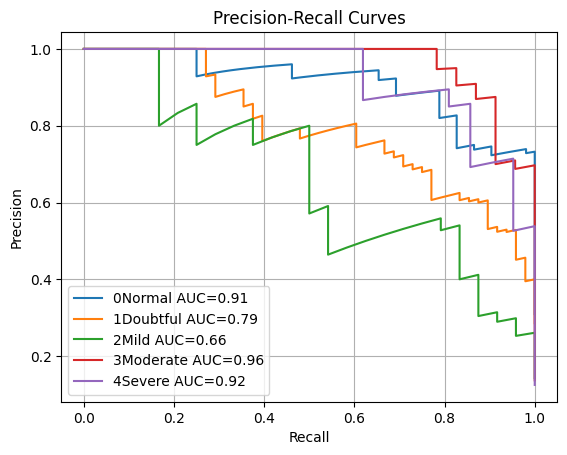

In [8]:
# Predict
y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_probs = model.predict(test_ds)
y_pred = np.argmax(y_probs, axis=1)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# AUROC per class
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)
auroc = roc_auc_score(y_true_onehot, y_probs, average=None)
for idx, auc_val in enumerate(auroc):
    print(f"AUROC for {class_names[idx]}: {auc_val:.4f}")

# AUPRC per class
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_onehot[:, i], y_probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{class_names[i]} AUC={pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()


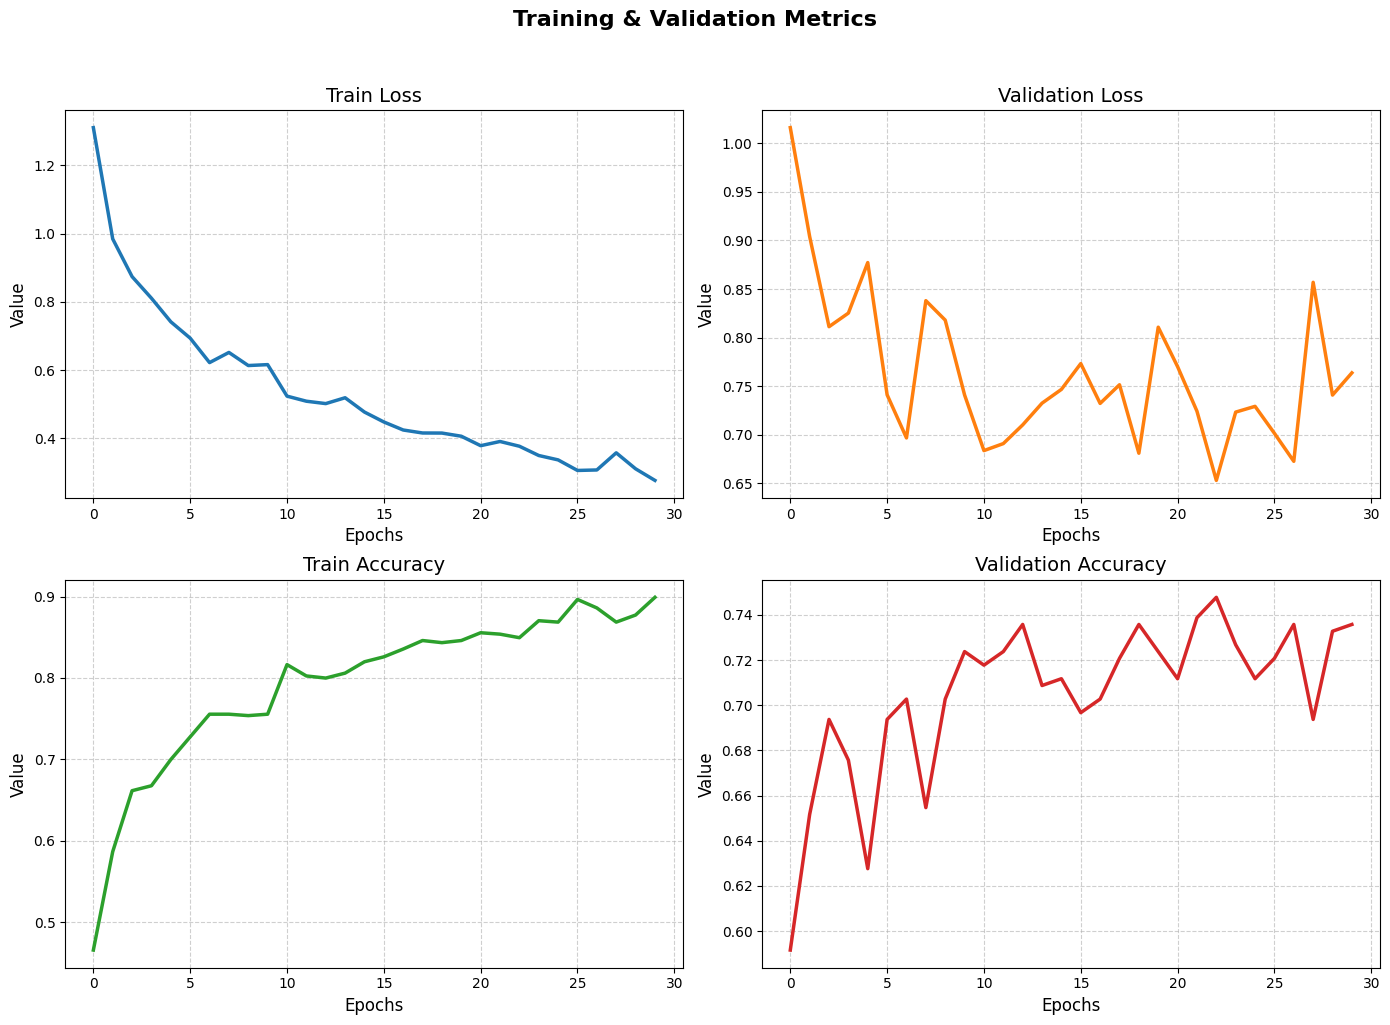

In [10]:
import matplotlib.pyplot as plt

def plot_history(history):
    metrics = {
        'Train Loss': history.history['loss'],
        'Validation Loss': history.history['val_loss'],
        'Train Accuracy': history.history['accuracy'],
        'Validation Accuracy': history.history['val_accuracy']
    }

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
   
    
    plt.figure(figsize=(14, 10))
    
    for i, (title, data) in enumerate(metrics.items(), 1):
        plt.subplot(2, 2, i)
        plt.plot(data, color=colors[i-1], linewidth=2.5)
        plt.title(title, fontsize=14)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
    
    plt.suptitle("Training & Validation Metrics", fontsize=16, fontweight='bold', y=1.02)
    plt.subplots_adjust(top=0.92)
    plt.show()

# Call the function with your model history
plot_history(history)


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


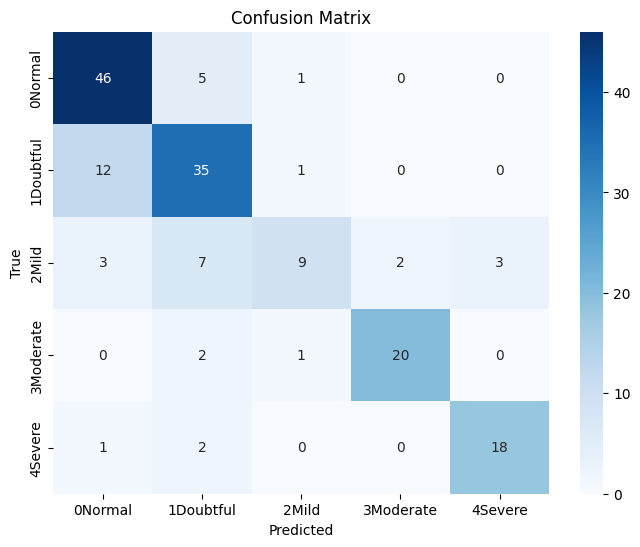

Classification Report:
              precision    recall  f1-score   support

     0Normal       0.74      0.88      0.81        52
   1Doubtful       0.69      0.73      0.71        48
       2Mild       0.75      0.38      0.50        24
   3Moderate       0.91      0.87      0.89        23
     4Severe       0.86      0.86      0.86        21

    accuracy                           0.76       168
   macro avg       0.79      0.74      0.75       168
weighted avg       0.76      0.76      0.75       168

Specificity for class 0Normal: 0.8621
Specificity for class 1Doubtful: 0.8667
Specificity for class 2Mild: 0.9792
Specificity for class 3Moderate: 0.9862
Specificity for class 4Severe: 0.9796
AUROC for class 0Normal: 0.9614
AUROC for class 1Doubtful: 0.8988
AUROC for class 2Mild: 0.9036
AUROC for class 3Moderate: 0.9925
AUROC for class 4Severe: 0.9854

AUPRC (Area under Precision-Recall Curve):
AUPRC for class 0Normal: 0.9099
AUPRC for class 1Doubtful: 0.7912
AUPRC for class 2Mild: 0

In [11]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# 1. True and predicted labels
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 3. Classification Report: Accuracy, Precision, Recall, F1
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Specificity Calculation
specificity = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity.append(specificity_i)

for i, s in enumerate(specificity):
    print(f"Specificity for class {class_names[i]}: {s:.4f}")

# 5. AUROC (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=range(num_classes))
try:
    aucs = roc_auc_score(y_true_bin, y_pred_probs, average=None)
    for i, auc_val in enumerate(aucs):
        print(f"AUROC for class {class_names[i]}: {auc_val:.4f}")
except ValueError:
    print("Not enough samples per class to calculate AUROC.")

# 6. AUPRC (One-vs-Rest)
print("\nAUPRC (Area under Precision-Recall Curve):")
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    auprc = auc(recall, precision)
    print(f"AUPRC for class {class_names[i]}: {auprc:.4f}")